# Introduction to `lamatrix`: Combining models

`lamatrix` enables you to combine `Model` objects to build more powerful models for your data. This tutorial will show how models can be combined.

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

First, we will make some fake data to fit. Here I'm creating data which is a combination of a simple polynomial, a sinusoid, and some noise terms.

In [2]:
x = np.arange(-5, 5, 0.01)
y = x * 2.3459 + 1.435 + np.random.normal(0, 0.3, size=len(x))
ye = np.ones(len(x)) * 0.3

y += 10*np.sin(x) + 10*np.cos(x)

If we plot the data we can see this is a simple trend

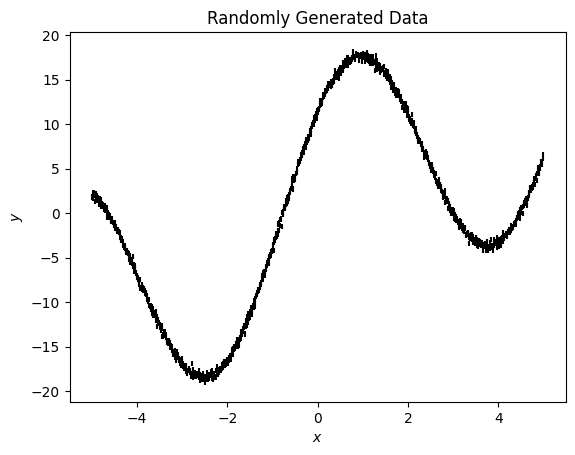

In [3]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

Now we will use `lamatrix` to fit this data. 

In [4]:
from lamatrix import Polynomial, Sinusoid, Constant

In this case, we know our model is a linear combination of these trends, so we simply add them together. Note we know both the polynomial and sinusoid are functions of the same variable, which we name `"x"`.

In [5]:
model = Polynomial('x', order=1) + Sinusoid('x') + Constant()

In [6]:
model

JointModel
	Polynomial(x)[n, 1]
	Sinusoid(x)[n, 2]
	Constant()[n, 1]

The model is now a `JointModel` where there are multiple components

We've combined different models, but we are still able to use it in the same way as a simple model. For example, here's the equation for the model

In [7]:
model.equation

'\\[f(\\mathbf{x}) = w_{0} \\mathbf{x}^{1} + w_{1} \\sin(\\mathbf{x}) + w_{2} \\cos(\\mathbf{x}) + w_{3} \\]'

Now we have the model, we can simply use the `fit` class method.

In [8]:
model.fit(x=x, data=y, errors=ye)

The model fit with no errors, let's look at the posterior distributions.

In [9]:
model.posteriors

DistributionContainer
	[(2.3465, 0.0034), (10.008, 0.013), (10.016, 0.014), (1.4568, 0.0099)]

We can see we've fit the posteriors with small errors. Let's compare to our inputs. Our input polynomial was

$2.3459x + 1.435$

Because `model` is a linear combination of objects, we can split this model back into it's components:

In [10]:
model

JointModel
	Polynomial(x)[n, 1]
	Sinusoid(x)[n, 2]
	Constant()[n, 1]

In [11]:
model[0]

Polynomial(x)[n, 1]

In [12]:
model[0].posteriors

DistributionContainer
	[(2.3465, 0.0034)]

We can see that the first order polynomial has posteriors after our fit. This is only a first order polynomial, and so it has only one weight. The weight is very close 
to our input weight of 2.346!

The polynomial we used was
$10.sin(x) + 10.cos(x)$. Let's look at the posteriors.

In [13]:
model[1]

Sinusoid(x)[n, 2]

In [14]:
model[1].equation

'\\[f(\\mathbf{x}) = w_{0} \\sin(\\mathbf{x}) + w_{1} \\cos(\\mathbf{x})\\]'

In [15]:
model[1].posteriors

DistributionContainer
	[(10.008, 0.013), (10.016, 0.014)]

This has two weights, one for sine and one for cosine. The weights are very close to the input amplitudes!

Finally we have the constant term

In [16]:
model[2]

Constant()[n, 1]

In [17]:
model[2].posteriors

DistributionContainer
	[(1.4568, 0.0099)]

This is very close to our input offset term. Let's plot the model to see how this looks

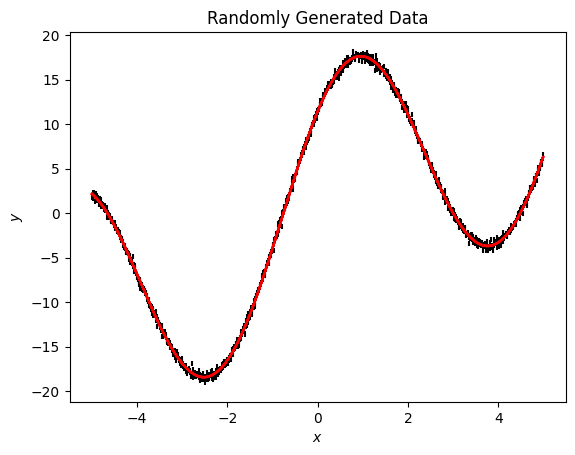

In [18]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, np.asarray([model.sample(x=x) for count in range(100)]).T, c='r', alpha=0.1);
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

This is a great fit to the data!

Here we've combined two types of model, a sinusoid and a polynomial, in order to fit the data we have. In this case, we knew the form of the models we should use. We can combine any number and any type of models in this way.

In this case we've fit a model where the two components are added, let's try a model where they are multiplied.

In [19]:
x = np.arange(-50, 50, 0.01)
y = x * 2.3459 + np.random.normal(0, 2, size=len(x))
ye = np.ones(len(x)) * 2

y *= 10*np.sin(x) + 10*np.cos(x)
y += 1.435

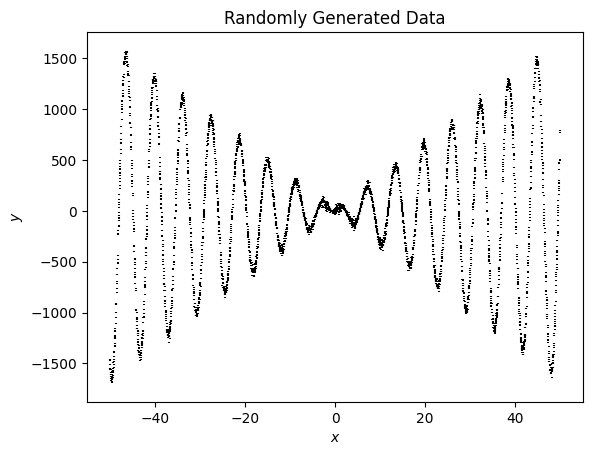

In [20]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

Now we need to multiply some components of the model

In [21]:
model = (Polynomial('x', order=3) * Sinusoid('x')) + Constant()

The model is now a `JointModel`, but inside the model is a `CrossTermModel`

In [22]:
model

JointModel
	CrosstermModel(x)[n, 6]
	Constant()[n, 1]

This crossterm model is the `Polynomial` multiplied by the `Sinusoid`

In [23]:
model[0]

CrosstermModel(x)[n, 6]

This model is now a polynomial multiplied by a sinusoid. Let's look at the equation

In [24]:
model[0].equation

'\\[f(\\mathbf{x}) = w_{0} \\mathbf{x}^{1}\\sin(\\mathbf{x}) + w_{1} \\mathbf{x}^{1}\\cos(\\mathbf{x}) + w_{2} \\mathbf{x}^{2}\\sin(\\mathbf{x}) + w_{3} \\mathbf{x}^{2}\\cos(\\mathbf{x}) + w_{4} \\mathbf{x}^{3}\\sin(\\mathbf{x}) + w_{5} \\mathbf{x}^{3}\\cos(\\mathbf{x})\\]'

We see in this model each term of the sinusoid model is multiplied by each term of the polynomial model. Note that a `CrosstermModel` can not be indexed into, because we can not split apart the various components. 

We can fit this model just like the one above to find the best fitting components

In [25]:
model.fit(x=x, data=y, errors=ye)

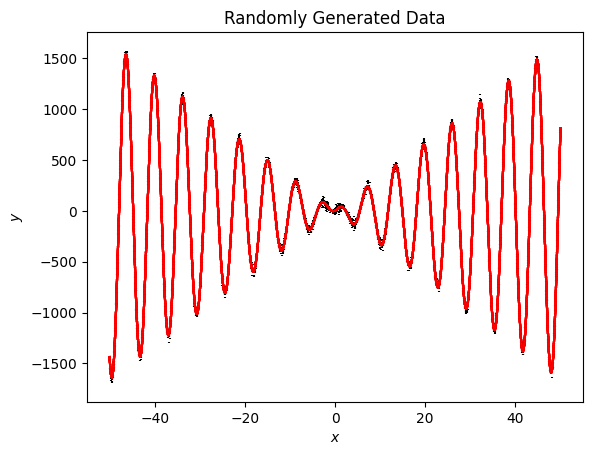

In [26]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, np.asarray([model.sample(x=x) for count in range(100)]).T, c='r', alpha=0.1);
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

This let's us find the best fitting weights for our combined model

In [27]:
model.posteriors

DistributionContainer
	[(23.4143, 0.0024), (23.4681, 0.0025), (0.000125, 2.5e-05), (0.000271, 2.6e-05), (2.64e-05, 1.5e-06), (-5.3e-06, 1.5e-06), (1.547, 0.02)]

We can save and load joint and crossterm models just like regular models 

In [28]:
model.save("output.json")

In [29]:
from lamatrix import load

In [42]:
load("output.json")

JointModel
	CrosstermModel(x)[n, 6]
	Constant()[n, 1]